# Module import

In [226]:
import sys
sys.path.insert(1, "../../module")
import numpy as np      
import snflics
from skimage.transform import resize
from netCDF4 import Dataset                             
from scipy.ndimage import zoom
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt                         
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")
from skimage import measure    
import json
import csv
from scipy.ndimage import label
import pandas as pd

# Matplotlib parameterisation

In [227]:
plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'

# Geodata

In [228]:
geodata = np.load("../../data/geodata/lat_lon_2268_2080.npz")
lons = geodata["lon"][:]
lats = geodata["lat"][:]

# Core data

In [229]:
# file of interest at time t0

#file = "../../data/core/202307031815.nc"
file = "../../data/core/core_20230715/202307152000.nc"
data = Dataset(file, mode='r')

# wavelet power maxima's coordinates
x0_lat = data["max_lat"][:]
x0_lon = data["max_lon"][:]

# cloud top temperature and wavelet power arrays
temp = data["tir"][0, :, :]
cores = data["cores"][0, :, :]
binary_cores = (cores != 0).astype(int)

# Plotting cores

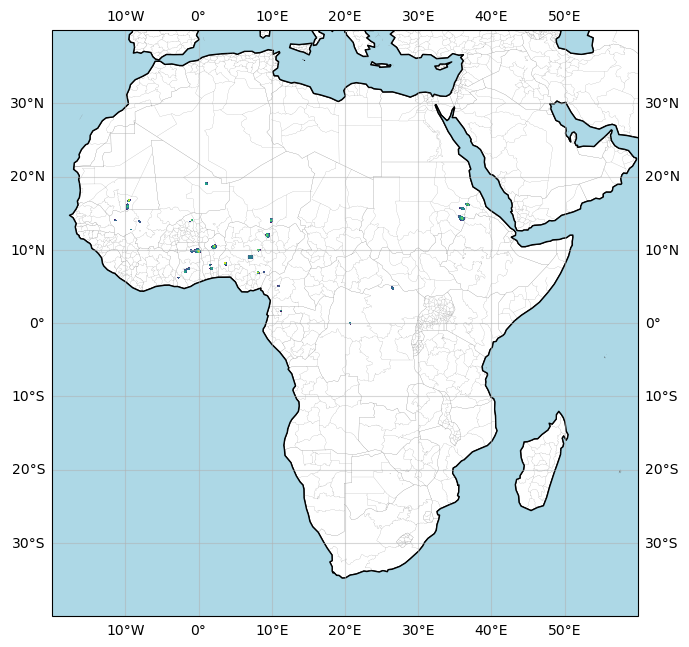

In [230]:
# Define extent
extent = (-20, 60, -40, 40)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 9), subplot_kw={'projection': ccrs.PlateCarree()})

# Force background to white
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')  # Optional

ax.gridlines(xlocs=np.arange(-20, 60, 10), 
             ylocs=np.arange(-40, 40, 10),
             draw_labels=True, 
             crs=ccrs.PlateCarree(),                
             alpha=0.5
            )

admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
    )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)
ax.add_feature(admin_borders, edgecolor='white', linewidth=0.07)

ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)

contour_core = ax.contourf(lons, lats, cores, levels=[40, 80, 120, 160, 200, 240, 280], transform=ccrs.PlateCarree(), cmap="viridis")

#for lt, ln in zip(x0_lat, x0_lon):    
  #plt.plot(ln, lt, marker="*", color="red", markersize=5)

plt.tight_layout()
plt.show()

### Finding all the cores (blobs)

- Using the average if we are interested in overall intensity, it is more robust

- less sensitive to noise

- useful for ranking general strenght or impact

What if I add some condition here to select only the wavelet power in the context domain?

In [231]:
# Long lead time (12x12)
CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX = 8.69, 20.69  # 8.69 + 12
CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX = -23.45, -11.45  # -23.45 + 12

In [232]:
in_region = (x0_lon >= CONTEXT_DOMAIN_LON_MIN) & (x0_lon <= CONTEXT_DOMAIN_LON_MAX) & (x0_lat >= CONTEXT_DOMAIN_LAT_MIN) & (x0_lat <= CONTEXT_DOMAIN_LAT_MAX)

In [233]:
in_region

masked_array(data=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False],
             mask=False,
       fill_value=True)

In [234]:
#x0_lon = x0_lon[in_region]
#x0_lat = x0_lat[in_region]

In [235]:
Dakar_lon = -17.467686
Dakar_lat = 14.716677

Dakar_y, Dakar_x = snflics.to_yx(Dakar_lat, Dakar_lon, lats, lons)

In [236]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Compute Haversine distance between two points or arrays of points.
    Inputs are in degrees. Output is in kilometers.
    
    Supports both scalar and array inputs (NumPy).
    """
    R = 6371.0  # Earth radius in kilometers

    # Convert degrees to radians
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [237]:
# Label the storm cores
labeled_array, num_cores = label(cores != 0)
core_labels = np.unique(labeled_array[labeled_array != 0])

# Compute storm sizes and mean wavelet power
dict_storm_size = {
    core_label: int(np.sum(labeled_array == core_label)) * 9
    for core_label in core_labels
}

dict_storm_intensity = {
    core_label: np.mean(cores[labeled_array == core_label])
    for core_label in core_labels
}

# Assign storm properties to each labeled storm using x0 coordinates
storm_database = {}
for lat, lon in zip(x0_lat, x0_lon):
    x0_y, x0_x = snflics.to_yx(lat, lon, lats, lons)
    lab = labeled_array[x0_y, x0_x]
    distance = haversine_distance(Dakar_lat, Dakar_lon, lat, lon)
    
    # Skip points not associated with a storm or already added
    if lab == 0 or lab in storm_database:
        continue

    storm_database[int(lab)] = {
        "lat": lat,
        "lon": lon,
        "wp": (dict_storm_intensity[lab]),
        "size": dict_storm_size[lab],
        "distance": distance,
        "mask": 1
    }

# Convert to pandas DataFrame
storm_df = pd.DataFrame.from_dict(storm_database, orient="index")
storm_df.index.name = "storm_label"
storm_df.reset_index(inplace=True)

In [238]:
storm_df

,storm_label,lat,lon,wp,size,distance,mask
0,1,0.000000,20.702862,114.107143,252,4503.616757,1
1,2,1.716897,11.279956,124.000000,144,3471.123502,1
2,3,4.721851,26.513077,108.379747,711,4936.654014,1
3,4,5.049491,10.935575,97.625000,432,3287.144506,1
4,5,6.207579,-2.715511,105.529412,153,1868.570559,1
5,6,6.933398,8.089476,159.223881,603,2919.270815,1
6,7,7.002083,-1.822207,114.884615,2340,1910.348239,1
7,8,6.936475,8.919554,87.055556,162,3005.705785,1
8,9,7.469258,1.797170,134.992366,1179,2249.498625,1
9,10,7.937025,1.581270,118.846154,468,2207.846470,1


In [239]:
len(storm_database) == len(x0_lat)

True

In [240]:
sorted_database = sorted(storm_database.items(), key=lambda item: item[1]['distance'])
closest_storms = sorted_database[:1]

In [241]:
fictional_storm = (0, {
    'lat': 14.0,            # Neutral value: roughly the middle of Western Sahel
    'lon': -5.0,            # Typical Western Sahel longitude (e.g., Mali region)
    'wp': 0.0,              # no intensity
    'size': 0,              # no size
    'distance': haversine_distance(14.0, -5.0, 14.69, -17.45),  # ~1340 km
    'mask': 0
})

In [242]:
def generate_storm_feature_header(n):
    """
    Generate a list of header names for n closest storms.
    Format: [lat1, lon1, ..., latN, lonN, wp1, ..., wpN, size1, ..., sizeN, d1, ..., dN, mask1, ..., maskN]
    """
    headers = []

    # Lat/Lon
    for i in range(1, n + 1):
        headers.append(f'lat{i}')
        headers.append(f'lon{i}')

    # Wavelet Power
    for i in range(1, n + 1):
        headers.append(f'wp{i}')

    # Size
    for i in range(1, n + 1):
        headers.append(f'size{i}')

    # Distance
    for i in range(1, n + 1):
        headers.append(f'd{i}')
    
    # Distance
    for i in range(1, n + 1):
        headers.append(f'mask{i}')

    return headers

In [243]:
def flatten_storm_features(closest_storms):
    """
    Given a list of closest storms [(id, dict), ...],
    return a flattened feature vector in the order:
    [lat1, lon1, ..., wp1, ..., size1, ..., distance1, ...]
    """
    lats_lons = []
    wps = []
    sizes = []
    distances = []
    masks = []

    for _, storm in closest_storms:
        lats_lons.extend([storm['lat'], storm['lon']])
        wps.append(storm['wp'])
        sizes.append(storm['size'])
        distances.append(storm['distance'])
        masks.append(storm['mask'])

    return lats_lons + wps + sizes + distances + masks


In [244]:
def generate_fictional_storm(city_lat, city_lon, min_distance_km=600,
                              lat_range=(10.0, 18.0), lon_range=(-20.0, 5.0)):
    while True:
        lat = np.random.uniform(*lat_range)
        lon = np.random.uniform(*lon_range)
        distance = haversine_distance(lat, lon, city_lat, city_lon)
        if distance > min_distance_km:
            return (0, {
                'lat': lat,
                'lon': lon,
                'wp': 0.0,
                'size': 0,
                'distance': distance,
                'mask': 0
            })

- Lat/lon values geographically plausible
- Distance realistic but safely irrelevant
- Domain adaptive to the forecast horizon

In [245]:
def get_padding_distance_km(lead_time_hours):
    if lead_time_hours <= 3:
        return 600
    elif lead_time_hours <= 6:
        return 1200
    else:
        return 1600

def get_domain_bounds(lead_time_hours):
    """
    Expand the Western Sahel bounding box based on lead time.
    """
    # Base bounds for short lead time
    base_lat_min, base_lat_max = 10.0, 18.0
    base_lon_min, base_lon_max = -20.0, 5.0

    if lead_time_hours <= 3:
        return base_lat_min, base_lat_max, base_lon_min, base_lon_max
    elif lead_time_hours <= 6:
        return 8.0, 20.0, -25.0, 10.0  # expanded domain
    else:
        return 5.0, 25.0, -30.0, 20.0  # much larger domain

def generate_fictional_storm(city_lat, city_lon, lead_time_hours):
    min_dist = get_padding_distance_km(lead_time_hours)
    lat_min, lat_max, lon_min, lon_max = get_domain_bounds(lead_time_hours)

    while True:
        lat = np.random.uniform(lat_min, lat_max)
        lon = np.random.uniform(lon_min, lon_max)
        distance = haversine_distance(lat, lon, city_lat, city_lon)
        if distance > min_dist:
            return (0, {
                'lat': lat,
                'lon': lon,
                'wp': 0.0,
                'size': 0,
                'distance': distance,
                'mask': 0
            })

In [246]:
generate_fictional_storm(Dakar_lat, Dakar_lon, 3)

(0,
 {'lat': 17.37873975093674,
  'lon': -8.93905600542803,
  'wp': 0.0,
  'size': 0,
  'distance': 958.0917523410156,
  'mask': 0})

In [247]:
def pad_closest_storms(sorted_database):
    if len(sorted_database) >= 3:
        return sorted_database[:3]
    else:
        needed = 3 - len(sorted_database)
        return sorted_database + [fictional_storm] * needed

In [248]:
storm_input = pad_closest_storms(closest_storms)

In [249]:
features = flatten_storm_features(storm_input)

In [250]:
with open("output.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(features)  # one row